# SHAP for length of stay all patients

In [1]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

## Define features to use



In [2]:
features = [
    'stroke_team',
    'age',
    'male',
    'ethnicity',
    'discharge_destination',
    'infarction',
    'arrive_by_ambulance',
    'onset_to_arrival_time',
    'arrival_to_scan_time',
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time',
    'congestive_heart_failure',
    'hypertension',
    'atrial_fibrillation',
    'diabetes',
    'prior_stroke_tia',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'prior_disability',
    'stroke_severity',
]

## Load and prepare data

In [3]:
all_data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)

In [4]:
# Filter data to teams with at least 300 admissions and 10 thrombolysis use
keep = []
groups = all_data.groupby('stroke_team') # creates a new object of groups of data

for index, group_df in groups: # each group has an index and a dataframe of data
    
    # Skip if total admission less than 300 or total thrombolysis < 10
    if (group_df.shape[0] < 300) or (group_df['thrombolysis'].sum() < 10):
        continue
    
    else: 
        keep.append(group_df)

# Concatenate output
data = pd.DataFrame()
data = pd.concat(keep)

n_patients_after_admission_restrictions = data.shape[0]
# Print the number of patients before and after applying the admission restrictions
print(f"Number of patients before admission restrictions: {all_data.shape[0]}")
print(f"Number of patients after admission restrictions: {n_patients_after_admission_restrictions}")
print("Difference in number of patients: ", all_data.shape[0] - n_patients_after_admission_restrictions)

Number of patients before admission restrictions: 452863
Number of patients after admission restrictions: 452115
Difference in number of patients:  748


In [5]:
# Drop any rows with no length of stay
data = data.dropna(subset=['length_of_stay'])

In [6]:
# Create  80:20 train-test split
X = data[features]
# One hot encode discharge_destination
y = data['length_of_stay']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
categorical_features = [
    'stroke_team',
    'ethnicity',
    'discharge_destination'
]

# Ensure categorical columns are true pandas categorical dtype for XGBoost
for col in categorical_features:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = pd.Categorical(X_test[col], categories=X_train[col].cat.categories)

## Fit model and get accuracy

In [8]:
# Fit XGBoost model, with categorical features specified
model = XGBRegressor(
    enable_categorical=True,
    seed=42
)

# Fit model
model.fit(X_train, y_train)

# Get R^2 score for predicted values
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2 score for the model on the test set: {r2:.4f}")

R^2 score for the model on the test set: 0.2825


## Get SHAP values and plot

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

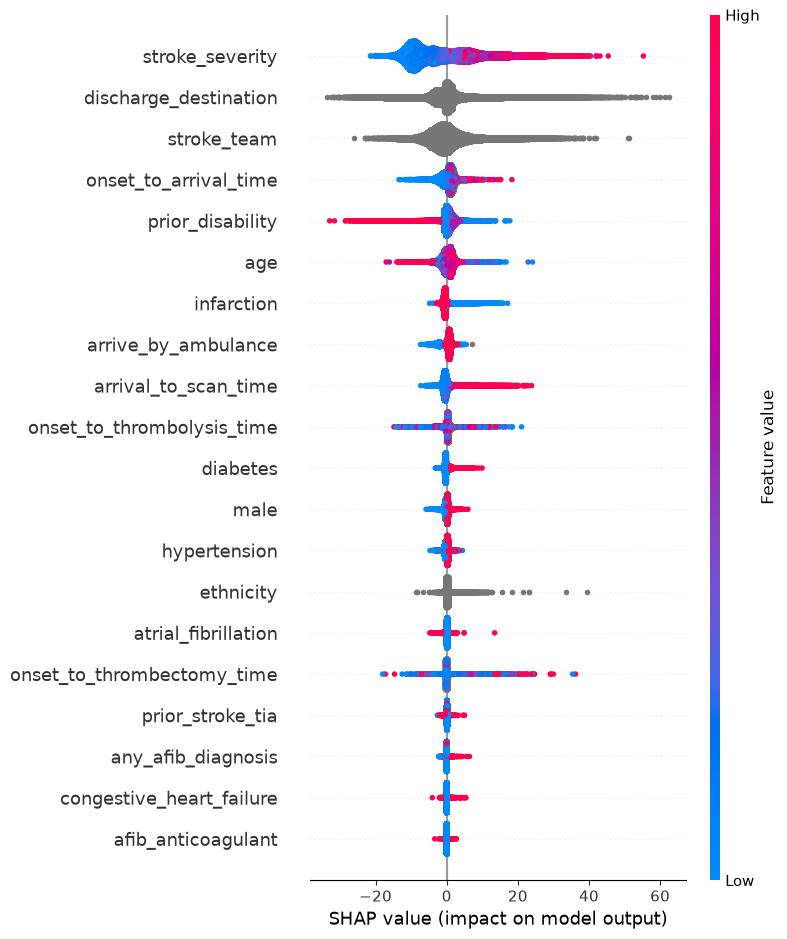

In [10]:
# Plot a beeswarm plot of SHAP values for the test set
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    max_display=X_test.shape[1],
    show=False)
plt.tight_layout()
plt.savefig("./output/shap_all_patients_los.png", dpi=300, bbox_inches="tight")
plt.show()

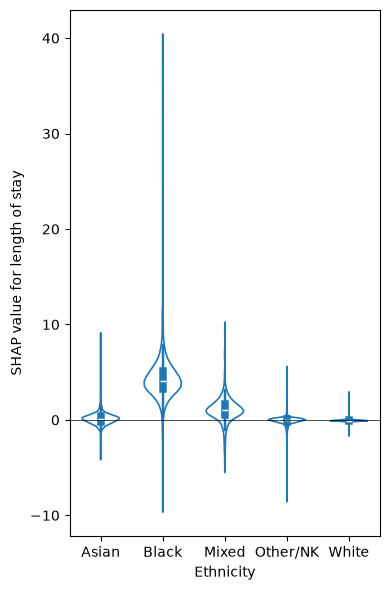

In [11]:
# Get feature and shap values for the ethncity feature
eth_idx = list(X.columns).index("ethnicity")
feature_values = X_test.iloc[:, eth_idx]
shap_values_ethnicity = shap_values[:, eth_idx] if isinstance(shap_values, np.ndarray) else shap_values[1][:, eth_idx]

# Plot as sns violin plot
plt.figure(figsize=(4, 6))
sns.violinplot(x=feature_values,
               y=shap_values_ethnicity,
               width=0.6,
               fill=False,
               inner="box",
               density_norm="width",
               linewidth=1.2)

plt.xlabel("Ethnicity")
plt.ylabel("SHAP value for length of stay")
#plt.title("Distribution of SHAP Values by Ethnicity")

# Add a line at y=0
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig("./output/shap_all_patients_los_ethnicity.png", dpi=300, bbox_inches="tight")
plt.show()

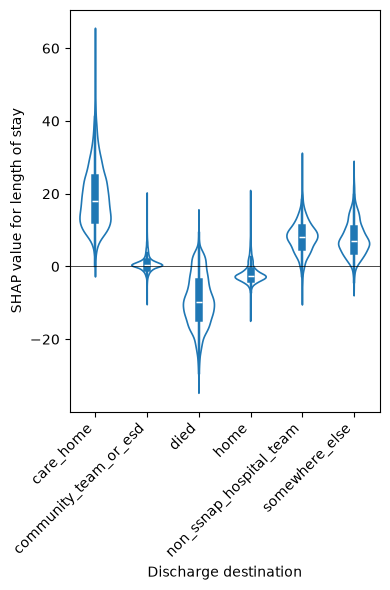

In [12]:
# Get feature and SHAP values for the discharge_destination feature
dd_idx = list(X.columns).index("discharge_destination")
feature_values = X_test.iloc[:, dd_idx]
shap_values_discharge_destination = (
    shap_values[:, dd_idx]
    if isinstance(shap_values, np.ndarray)
    else shap_values[1][:, dd_idx]
)

# Plot as seaborn violin plot
plt.figure(figsize=(4, 6))
sns.violinplot(
    x=feature_values,
    y=shap_values_discharge_destination,
    width=0.6,
    fill=False,
    inner="box",
    density_norm="width",
    linewidth=1.2,
)

# Put X axis labels 45 degrees, and right align with tick labels
plt.xticks(rotation=45, ha="right")

plt.xlabel("Discharge destination")
plt.ylabel("SHAP value for length of stay")

# Add a line at y=0
plt.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.savefig("./output/shap_all_patients_los_discharge_destination.png", dpi=300, bbox_inches="tight")
plt.show()

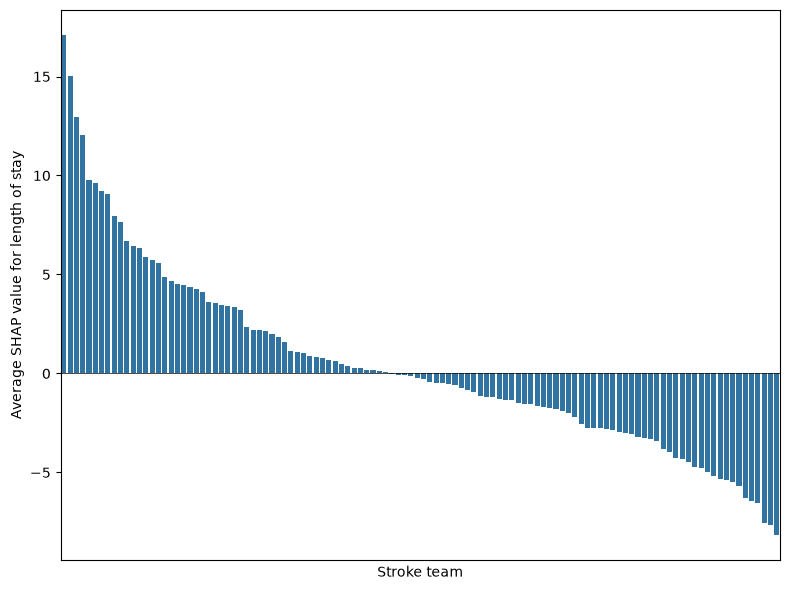

In [13]:
# Get SHAP values for the stroke_team feature, average for each team
stroke_team_idx = list(X.columns).index("stroke_team")
feature_values = X_test.iloc[:, stroke_team_idx]
shap_values_stroke_team = shap_values[:, stroke_team_idx] if isinstance(shap_values, np.ndarray) else shap_values[1][:, stroke_team_idx]

# Average SHAP values for each stroke team
stroke_team_shap_df = pd.DataFrame({
    'stroke_team': feature_values,
    'shap_value': shap_values_stroke_team
})
stroke_team_shap_df = stroke_team_shap_df.groupby('stroke_team').mean().reset_index()

# Sort by SHAP value
stroke_team_shap_df = stroke_team_shap_df.sort_values(by='shap_value', ascending=False)
team_order = (
    stroke_team_shap_df
    .groupby("stroke_team")["shap_value"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Plot as sns bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=stroke_team_shap_df,
    order=team_order,
    x="stroke_team",
    y="shap_value",
)

# Remove the individual tick labels (team names) and tick marks
ax.set_xticks([])

plt.xlabel("Stroke team")
plt.ylabel("Average SHAP value for length of stay")
#plt.title("Average SHAP Values by Stroke Team")
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig("./output/shap_all_patients_los_stroke_team.png", dpi=300, bbox_inches="tight")
plt.show()